In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
customer_df = pd.read_excel('/Users/chrishegangkim/Desktop/2025 Spring/Python/Data Analysis Project/전처리된파일.xlsx')

pd.set_option('display.max_columns', None)
customer_df.head()

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_total,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,2020-12,58,75579400,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,15,3,0,0,0,0,0,1
1,2022-06,61,60247200,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,5,2,0,0,0,0,0,0
2,2021-11,50,93096900,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,19,1,0,0,0,0,0,0
3,2022-05,31,34639800,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,8,2,0,0,0,0,0,0
4,2022-04,34,75780900,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,16,5,0,0,0,0,0,0


In [30]:
#나이 분포 파악하기
plt.rc('font', family = 'AppleGothic') #한글 지원 폰트를 설정하기

Text(0, 0.5, '고객 수 (명)')

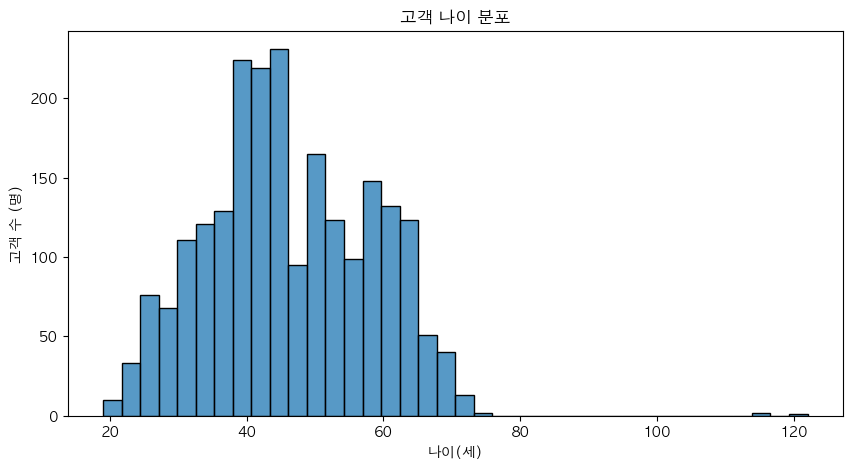

In [32]:
plt.rcParams['figure.figsize'] = (10, 5) #히스토그램 그리고 이름까지 설정하기
sns.histplot(data=customer_df['age'])
plt.title('고객 나이 분포')
plt.xlabel('나이(세)')
plt.ylabel('고객 수 (명)')

In [34]:
customer_df.sort_values(by = 'age', ascending = False) #나이가 많은 순으로 정렬하기

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_total,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
228,2022-08,122,78236600,미혼,1,23,10400,0,6500,9100,0,2600,28600,1,2,4,1,0,0,0,0,0,0
326,2021-12,116,108591600,배우자 있음,0,36,981500,187200,730600,135200,83200,291200,2408900,4,4,9,1,0,0,0,0,1,0
181,2021-12,115,47632000,이혼,1,99,19500,7800,10400,9100,5200,32500,84500,2,2,5,1,0,0,0,0,0,0
1933,2021-10,75,66483300,미혼,0,96,187200,0,9100,0,0,7800,204100,3,4,8,1,0,0,0,0,0,0
411,2021-07,74,120935100,배우자 있음,0,77,1670500,54600,930800,71500,0,27300,2754700,7,5,12,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734,2022-06,20,92511900,미혼,0,30,367900,22100,483600,179400,137800,57200,1248000,3,12,16,1,0,0,0,0,0,0
2190,2021-01,20,104802100,미혼,0,42,772200,66300,820300,93600,71500,41600,1865500,4,8,13,1,0,0,0,0,0,0
1833,2020-12,20,108234100,미혼,0,56,696800,35100,767000,49400,139100,87100,1774500,5,12,18,1,0,0,1,0,1,1
1157,2022-05,19,18747300,배우자 있음,0,81,0,0,2600,3900,3900,10400,20800,1,2,4,1,0,0,1,0,0,0


In [36]:
customer_df = customer_df[customer_df['age'] < 100] #100세 미만의 고객만 골라 변수에 다시 담기

Text(0, 0.5, '고객 수(명)')

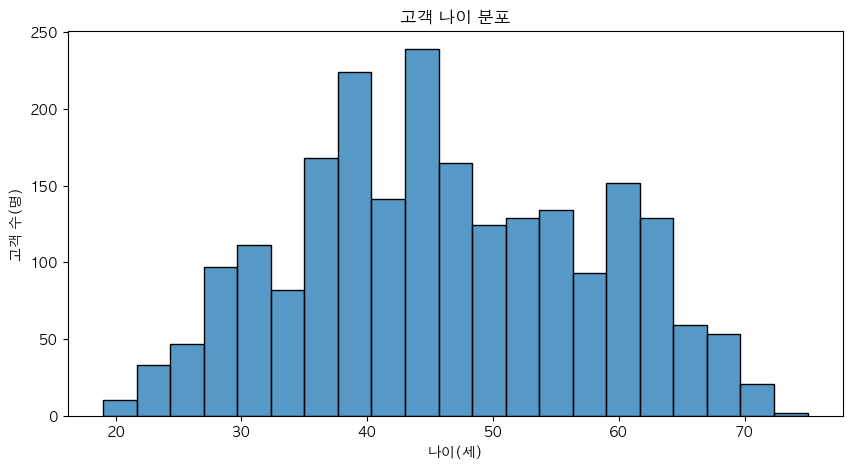

In [38]:
sns.histplot(data = customer_df['age'])
plt.title('고객 나이 분포')
plt.xlabel('나이(세)')
plt.ylabel('고객 수(명)')

In [40]:
age_bins = list(range(10, 81, 10)) #10부터 80까지 나눈 구간을 리스트로 표현하여 변수에 먼저 넣기
age_bins

[10, 20, 30, 40, 50, 60, 70, 80]

In [44]:
age_labels = [f'{x}대' for x in age_bins[:-1]] #문자열 리스트를 만들고 마지막 원소를 제외하고 list comprehension 코드를 작성하기
age_labels

['10대', '20대', '30대', '40대', '50대', '60대', '70대']

In [46]:
age_group = pd.cut(x = customer_df['age'], bins = age_bins, labels = age_labels, right = False) #연령대 구간을 나누기

In [48]:
customer_df.insert(loc = customer_df.columns.get_loc('age') + 1, column = 'age_group', value = age_group) #구간화한 데이터 컬럼을 넣기
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_total,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,2020-12,58,50대,75579400,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,15,3,0,0,0,0,0,1
1,2022-06,61,60대,60247200,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,5,2,0,0,0,0,0,0
2,2021-11,50,50대,93096900,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,19,1,0,0,0,0,0,0
3,2022-05,31,30대,34639800,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,8,2,0,0,0,0,0,0
4,2022-04,34,30대,75780900,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,16,5,0,0,0,0,0,0


In [50]:
customer_df['age_group'].value_counts()

age_group
40대    678
30대    502
50대    485
60대    338
20대    185
70대     23
10대      2
Name: count, dtype: int64

In [64]:
age_group_replace_dict = {'10대' : '20대 이하', '20대' : '20대 이하', '60대' : '60대 이상', '70대' : '60대 이상'}
#딕셔너리 키에는 기존 값을, 키에 대응하는 밸류에는 새로운 값을 넣어 데이터 내 특정 값을 따른 값으로 바꾸기
customer_df['age_group'] = customer_df['age_group'].replace(age_group_replace_dict)

In [66]:
customer_df['age_group'].value_counts()

age_group
40대       678
30대       502
50대       485
60대 이상    361
20대 이하    187
Name: count, dtype: int64

Text(0, 0.5, '고객 수(명)')

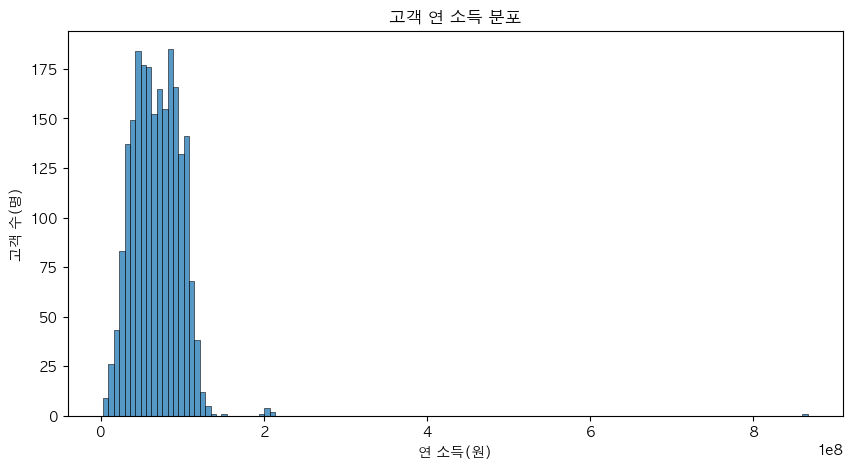

In [70]:
#연 소득 분포 파악하기
sns.histplot(data = customer_df['annual_income'])
plt.title('고객 연 소득 분포')
plt.xlabel('연 소득(원)')
plt.ylabel('고객 수(명)')

<Axes: xlabel='annual_income'>

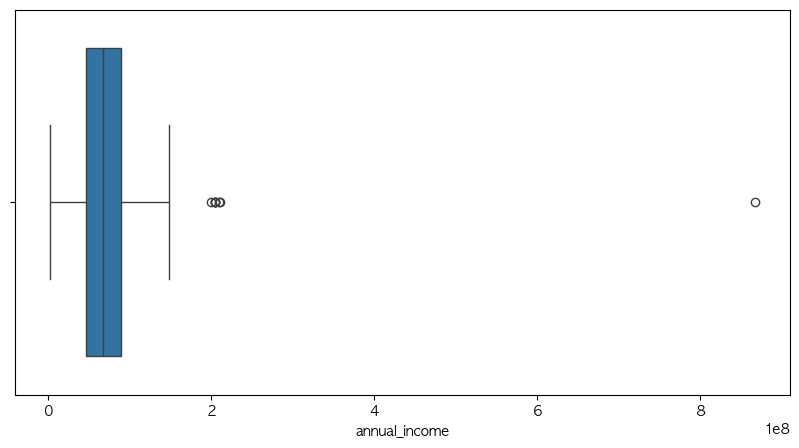

In [86]:
sns.boxplot(data = customer_df, x = 'annual_income') #이상값 존재 확인하기

In [90]:
income = customer_df['annual_income'] #IQR 사이에 있는 데이터만 남기기
q1 = income.quantile(0.25)
q3 = income.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 - 1.5 * iqr

normal_condition = (lower_bound <= income) & (income <= upper_bound)
customer_df = customer_df[normal_condition]

<Axes: xlabel='annual_income'>

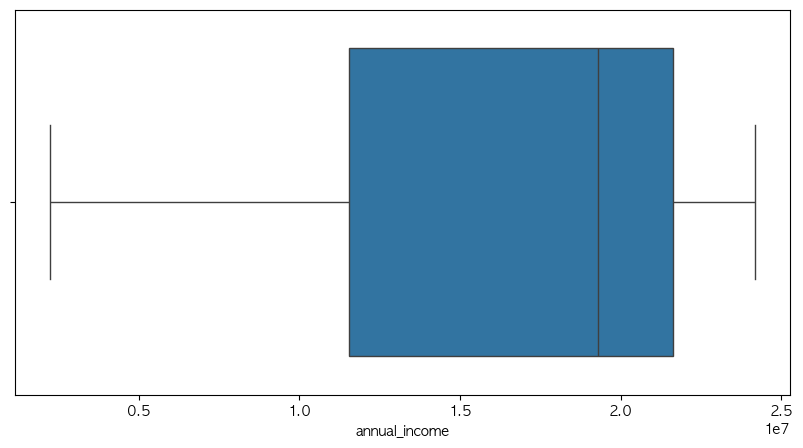

In [92]:
sns.boxplot(data = customer_df, x = 'annual_income')